# **BLIP와 LLaVA**

## 1.환경준비

* 설치

In [ ]:
!pip install -U "transformers>=4.40,<4.48" accelerate pillow sentencepiece einops -q

* 라이브러리 로딩

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from transformers import pipeline
import torch
from PIL import Image

import tqdm as notebook_tqdm

# 디바이스 준비
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2.BLIP 사용해보기

### (1) 이미지 캡셔닝

* 이미지 → 텍스트 캡션 파이프라인 준비

In [5]:
cap_pipe = pipeline(
    task="image-to-text",
    model="Salesforce/blip-image-captioning-base",
    device=device
)

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\transformers\models\auto\modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda


* 테스트 파일 준비

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 cat_bird.jpg 선택

* 이미지 캡셔닝 테스트

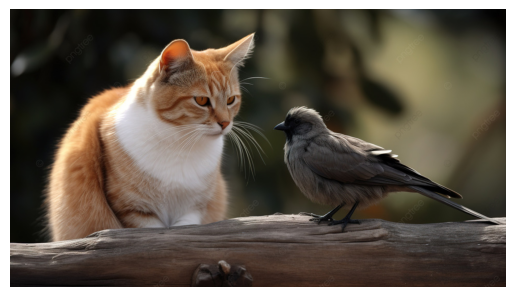

Caption: a cat and a bird are sitting on a log


In [6]:
# 테스트용 이미지 경로
img_path = "./data/cat_bird.jpg"   # 로컬에 있는 이미지 파일로 바꿔주세요

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

# 캡션 생성
cap = cap_pipe(img_path, max_new_tokens=30)[0]["generated_text"]
print("Caption:", cap)

### (2) Vision QA

* 시각 질의응답 모델 파이프라인

In [7]:
vqa_pipe = pipeline(
    task="visual-question-answering",
    model="Salesforce/blip-vqa-base",
    device=device
)

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--Salesforce--blip-vqa-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Device set to use cuda


* 테스트 파일 준비

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 beach_children.jpg 선택

* VQA 테스트

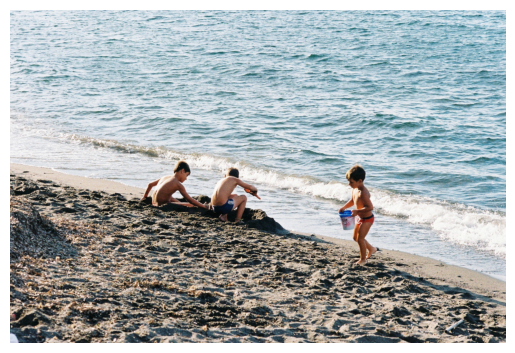

Q: What are they doing?
A: playing



In [9]:
# VQA 질문 준비
img_path = "./data/beach_children.jpg"
questions = ["What are they doing?"]

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

for q in questions:
    ans = vqa_pipe(image=img_path, question=q)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

### (3) 실습
* 이미지를 한장 업로드해서 이미지 캡셔닝 및 VQA를 수행해 봅니다.

In [ ]:
from google.colab import files
uploaded = files.upload()
img_path2 = "your_image.jpg"

* 이미지 캡셔닝

Caption: [{'answer': 'circle'}]


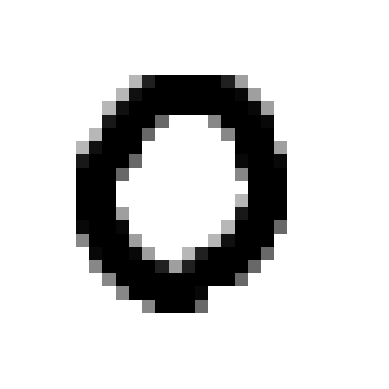

In [12]:
img_path2 = "./data/0.png"
img2 = Image.open(img_path2)

question = "What is in this picture?"
cap = vqa_pipe({"image": img2, "question": question})
print("Caption:", cap)

img = Image.open(img_path2).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()


* Vision QA

In [ ]:
img_path = "./data/0.png"
img = Image.open(img_path)

# VQA 질문 준비
questions = [
    "What is in this picture?",
    "What color is the object?",
    "Is it indoors or outdoors?",
    "How many objects are there?"
]

for q in questions:
    result = vqa_pipe({"image": img, "question": q})
    ans = result[0]['answer']  # 결과에서 답변 추출
    print(f"Q: {q}\nA: {ans}\n")

Q: What is in this picture?
A: circle

Q: What color is the object?
A: black

Q: Is it indoors or outdoors?
A: outdoors

Q: How many objects are there?
A: 1



## 3.LLaVA 사용해보기

* tiny-llava 모델은 pipeline 함수로 지원 안됨

### (1) 모델 다운로드

In [3]:
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "bczhou/tiny-llava-v1-hf"

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    low_cpu_mem_usage=True,
).to(device)

processor = AutoProcessor.from_pretrained(model_id)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:06<00:00,  3.17s/it]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### (2) 모델 사용

In [10]:
img = Image.open("./data/beach_children.jpg").convert("RGB")
prompt = "USER: <image> What do you see in this picture? ASSISTANT:"

# 1) images 먼저, text 다음 (키워드 인자 사용 권장)
inputs = processor(images=img, text=prompt, return_tensors="pt")

# 2) 딕셔너리의 텐서들만 각각 device로 이동
inputs = {k: v.to(device) for k, v in inputs.items()}

# (선택) float16 환경이면 pixel_values를 float16으로 바꿔주기
if torch.cuda.is_available() and dtype == torch.float16 and "pixel_values" in inputs:
    inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)

with torch.inference_mode():
    output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

# 프롬프트 길이만큼 잘라서 모델 답변 부분만 디코딩
answer = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(answer)

TypeError: unsupported operand type(s) for //: 'int' and 'NoneType'

### (3) 실습
* BLIP 실습에서 업로드한 이미지를 사용합니다.
* VQA를 위한 프롬프트를 작성하여 결과를 확인해 봅시다.

In [ ]:
prompt =

inputs = processor(prompt, img2, return_tensors="pt").to(device)

with torch.inference_mode():
    output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

answer = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(answer)

## 4.BLIP와 LLaVA 비교

### (1) 테스트 이미지와 질문 준비

In [ ]:
# 이미 업로드한 파일 사용
img_path = "beach_children.jpg"
img = Image.open(img_path).convert("RGB")
questions = ["What is in the image?", "How many people are there?", "Describe the scene."]

### (2) 두 모델 비교

In [ ]:
#  BLIP 실행
print("=== BLIP (Salesforce/blip-vqa-base) ===================")
for q in questions:
    ans = vqa_pipe(img, q, max_new_tokens=32)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

#  LLaVA 실행
print("=== LLaVA (bczhou/tiny-llava-v1-hf) ===================")
for q in questions:
    prompt = f"USER: <image>\n{q}\nASSISTANT:"
    inputs = processor(prompt, img, return_tensors="pt").to(
        device,
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    answer = processor.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {q}\nA: {answer}\n")

### (3) 실습
새로운 이미지를 찾아서 비교해 봅시다

* 이미지 업로드 및 저장

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 cat_bird.jpg 선택

img_path = "your image.jpg"



* 테스트 질문 저장

In [ ]:
questions = [    ]

* 모델 비교

In [ ]:
#  BLIP 실행
print("=== BLIP (Salesforce/blip-vqa-base) ===================")
for q in questions:
    ans = vqa_pipe(img, q, max_new_tokens=32)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

#  LLaVA 실행
print("=== LLaVA (bczhou/tiny-llava-v1-hf) ===================")
for q in questions:
    prompt = f"USER: <image>\n{q}\nASSISTANT:"
    inputs = processor(prompt, img, return_tensors="pt").to(
        device,
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    answer = processor.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {q}\nA: {answer}\n")